In [3]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider



## Supercritical hopf bifurcation
1. Goes from stable spiral to an unstable spiral
2. Eigenvalues have mew as the real term: therefore, mu going from (-) to (+) causes stable to unstable

### images


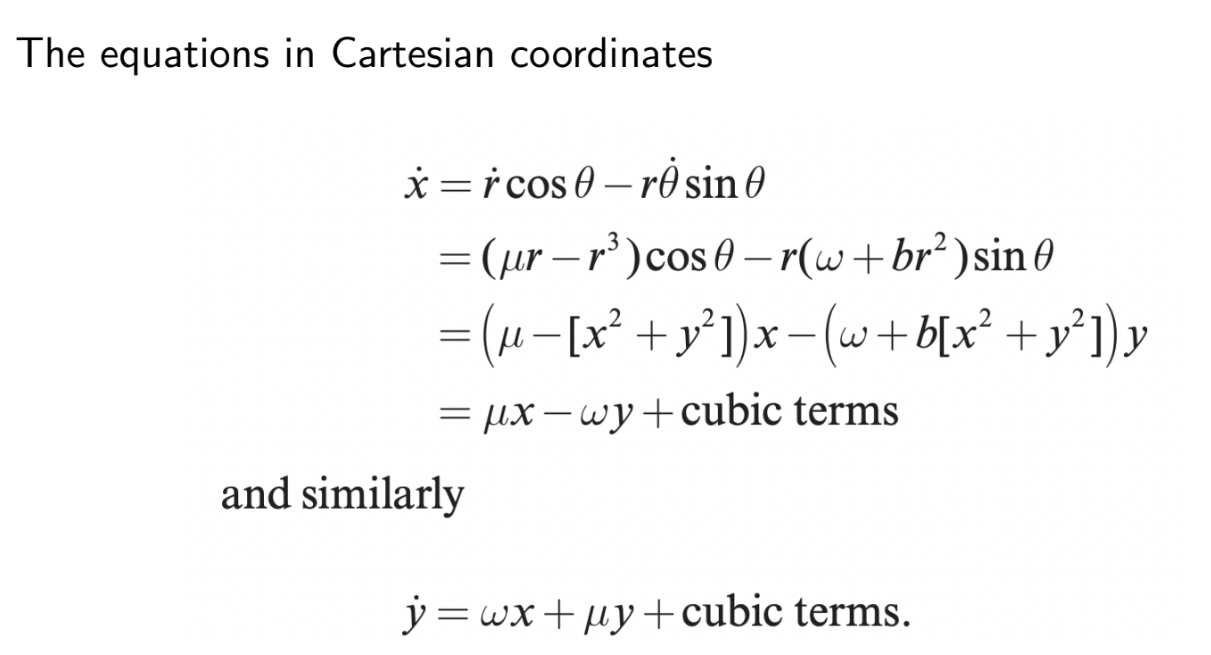 
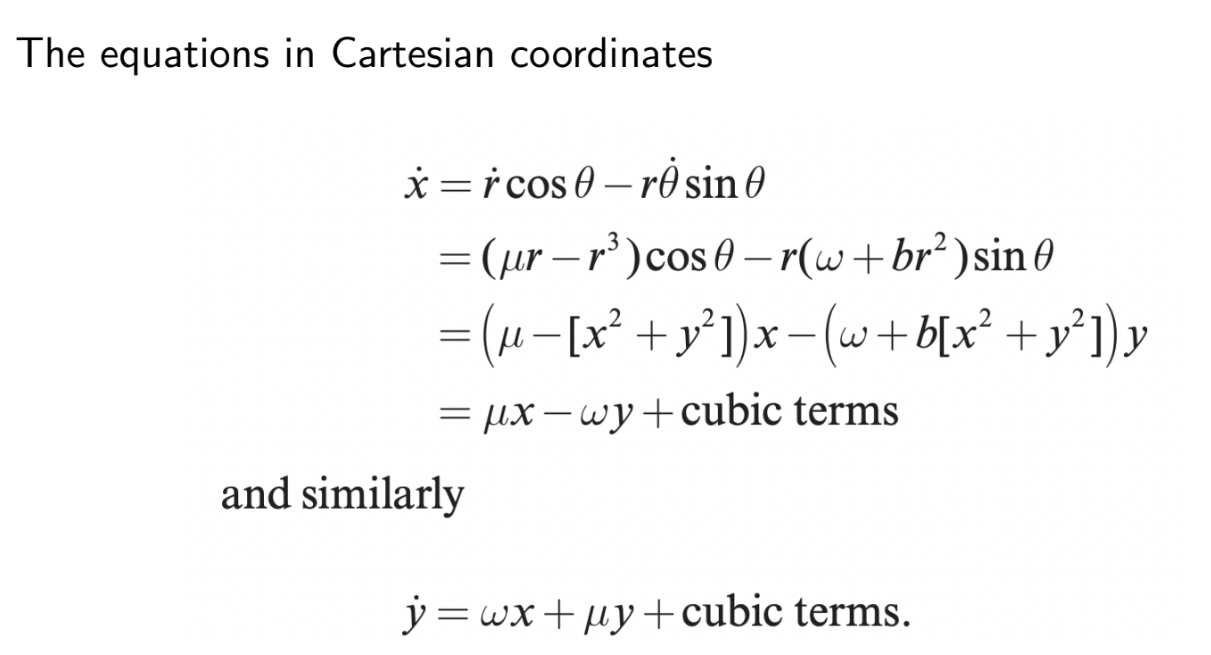
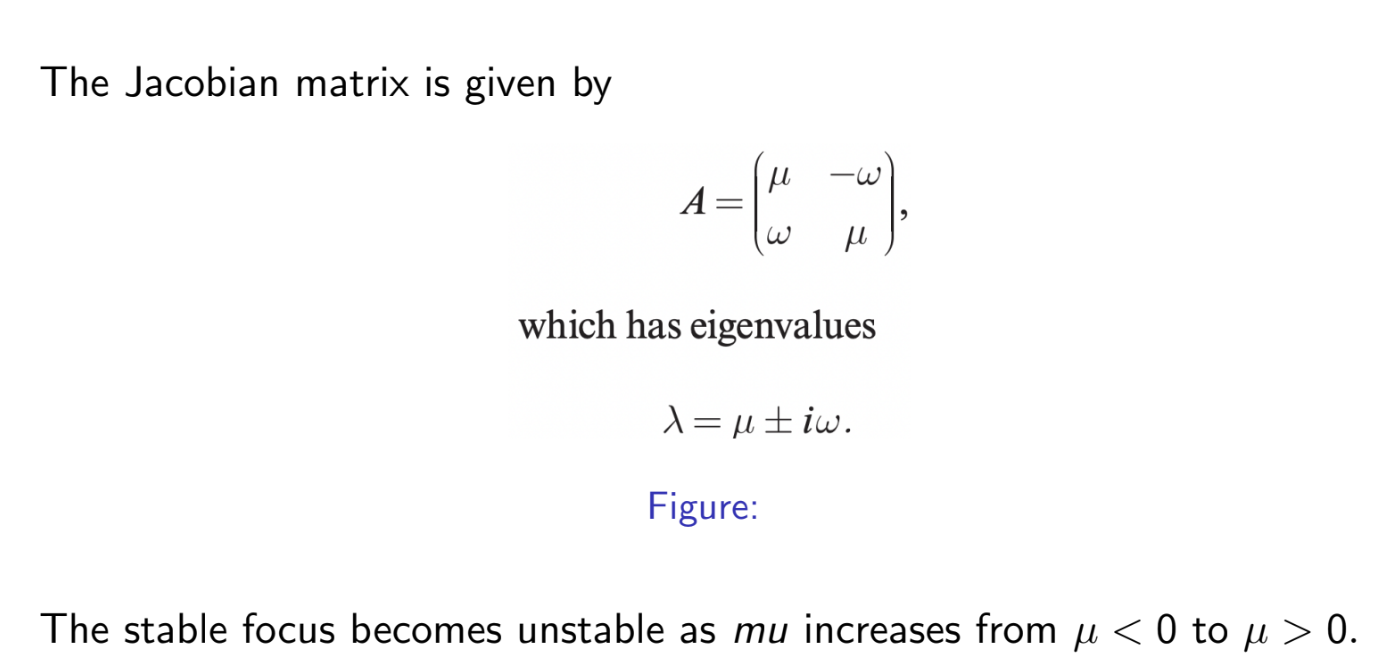

## code

In [18]:
# --- radial vector fields ---
def f_super(r, mu):
    return mu * r - r**3

# -------------------
# Supercritical Hopf plot
# -------------------
def plot_supercritical(mu, ylimit=1.5, rmax=3.0):
    r = np.linspace(0.0, rmax, 600)
    f_sup = f_super(r, mu)

    plt.figure(figsize=(6,4))
    plt.plot(r, f_sup, lw=2)
    plt.axhline(0, color='k', lw=0.8)
    plt.ylim(-ylimit, ylimit)
    plt.xlim(0, rmax)
    plt.title(f"Supercritical Hopf (μ={mu:.3f})")
    plt.xlabel("r")
    plt.ylabel(r"$\dot{r}$")
    plt.grid(alpha=0.3)

    # roots
    super_roots = [0.0]
    if mu > 0:
        super_roots.append(np.sqrt(mu))
    for rr in super_roots:
        slope = (mu - 3 * rr**2)
        color = 'g' if slope < 0 else 'r'
        plt.plot(rr, 0.0, 'o', color=color, ms=10)

    plt.annotate(f"d/dr at 0 = {mu:.3g}", xy=(0.05, 0.9), xycoords='axes fraction')
    plt.show()



In [19]:
# -------------------
# Interactive widgets
# -------------------
print("Supercritical Hopf:")
interact(
    plot_supercritical,
    mu=FloatSlider(value=0.0, min=-1.0, max=1.0, step=0.01, description="μ"),
    ylimit=FloatSlider(value=1.5, min=0.2, max=5.0, step=0.1, description="y-limit"),
)



Supercritical Hopf:


interactive(children=(FloatSlider(value=0.0, description='μ', max=1.0, min=-1.0, step=0.01), FloatSlider(value…

<function __main__.plot_supercritical(mu, ylimit=1.5, rmax=3.0)>

## Subcritical Hopf Bifurcation

### images

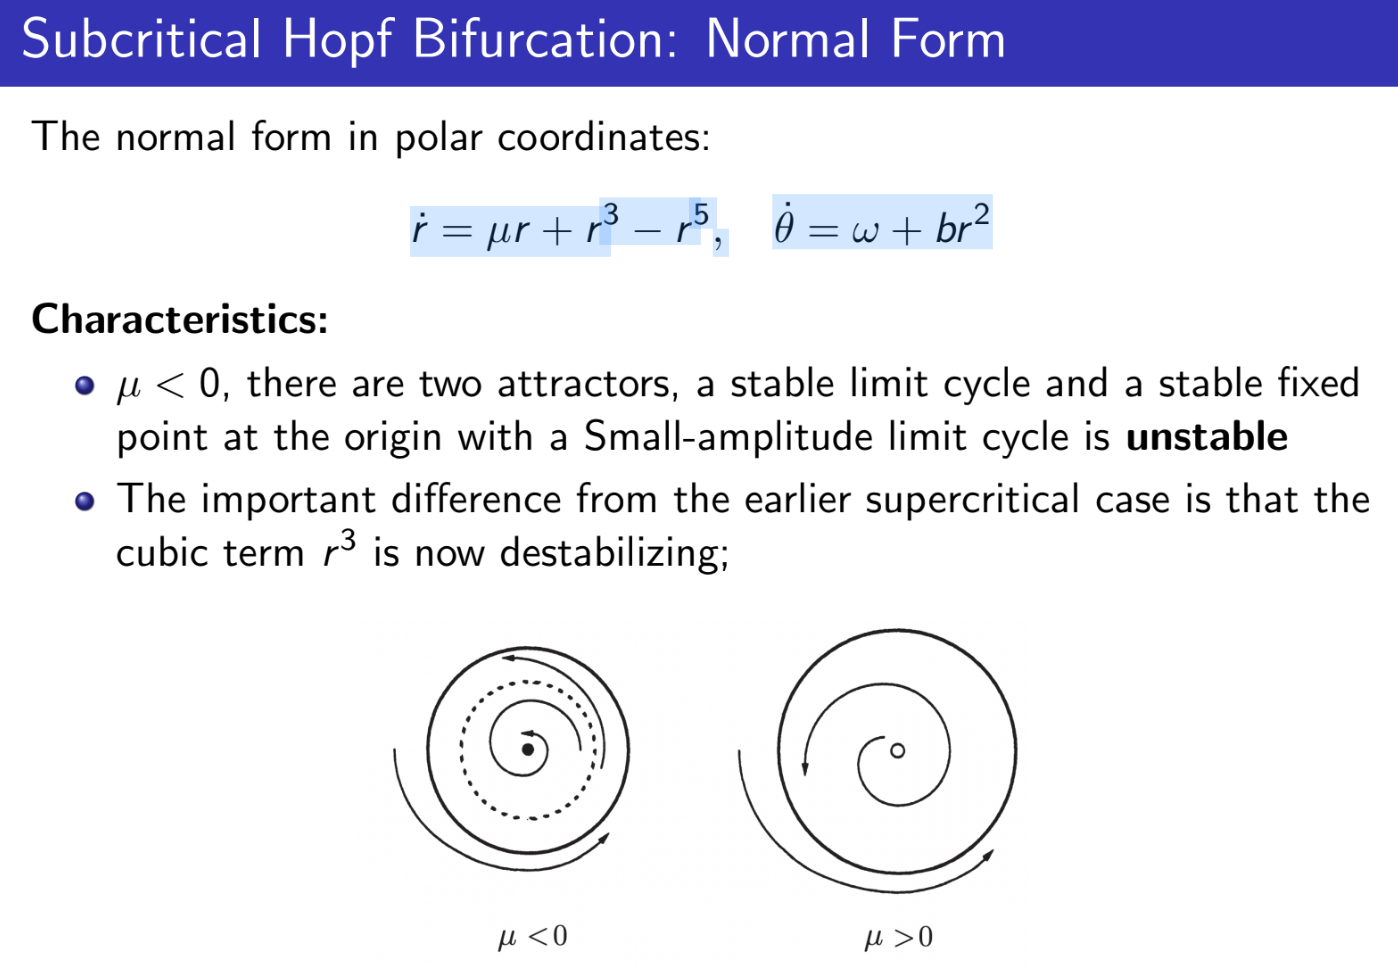

## code


In [22]:
def f_sub(r, mu):
    '''define state equation for subcritical hopf bifurcation'''
    return mu * r + r**3 - r**5

# Solve subcritical nullcline roots robustly:
def sub_positive_roots(mu):
    '''return positive real roots of subcritical hopf nullcline as a list'''
    disc = 1.0 + 4.0 * mu
    roots_r = []
    if disc >= 0:
        s1 = (1.0 + np.sqrt(disc)) / 2.0
        s2 = (1.0 - np.sqrt(disc)) / 2.0
        for s in (s1, s2):
            if s >= 0:
                roots_r.append(np.sqrt(s))
    roots_r = sorted(list(set(np.round(np.array(roots_r), 12))))
    return roots_r


# -------------------
# Subcritical Hopf plot
# -------------------
def plot_subcritical(mu, ylimit=1.5, rmax=3.0):
    r = np.linspace(0.0, rmax, 600)
    f_subc = f_sub(r, mu)

    plt.figure(figsize=(6,4))
    plt.plot(r, f_subc, lw=2)
    plt.axhline(0, color='k', lw=0.8)
    plt.ylim(-ylimit, ylimit)
    plt.xlim(0, rmax)
    plt.title(f"Subcritical Hopf (μ={mu:.3f})")
    plt.xlabel("r")
    plt.ylabel(r"$\dot{r}$")
    plt.grid(alpha=0.3)

    # roots
    sub_roots = [0.0] + sub_positive_roots(mu)
    for rr in sub_roots:
        slope = (mu + 3 * rr**2 - 5 * rr**4)
        color = 'g' if slope < 0 else 'r'
        plt.plot(rr, 0.0, 'o', color=color, ms=10)

    # annotate s-roots
    s_roots = []
    disc = 1.0 + 4.0*mu
    if disc >= 0:
        s_roots = [ (1.0 + np.sqrt(disc))/2.0, (1.0 - np.sqrt(disc))/2.0 ]
    plt.annotate("s-roots (r^2):\n" + ", ".join([f"{s:.3g}" for s in s_roots]) if s_roots else "no real s-roots",
                 xy=(0.02, 0.85), xycoords='axes fraction')
    plt.show()



## Subcritical Hopf Bifurcation

In [23]:

print("Subcritical Hopf:")
interact(
    plot_subcritical,
    mu=FloatSlider(value=0.0, min=-1.0, max=1.0, step=0.01, description="μ"),
    ylimit=FloatSlider(value=1.5, min=0.2, max=5.0, step=0.1, description="y-limit"),
)

Subcritical Hopf:


interactive(children=(FloatSlider(value=0.0, description='μ', max=1.0, min=-1.0, step=0.01), FloatSlider(value…

<function __main__.plot_subcritical(mu, ylimit=1.5, rmax=3.0)>

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from ipywidgets import interact, FloatSlider


def hopf(t, xy, mu, omega):
    x, y = xy
    r2 = x*x + y*y
    dx = (mu - r2) * x - omega * y
    dy = (mu - r2) * y + omega * x
    return [dx, dy]

def simulate(mu, omega=2*np.pi, x0=0.2, y0=0.1, t_end=60.0, npoints=2000):
    t_eval = np.linspace(0, t_end, npoints)
    sol = solve_ivp(hopf, [0, t_end], [x0, y0], args=(mu, omega), t_eval=t_eval,
                    rtol=1e-6, atol=1e-9)
    x, y = sol.y
    r = np.sqrt(x**2 + y**2)
    return sol.t, x, y, r

def asymptotic_radius_from_sim(t, r, frac_discard=0.6):
    n0 = int(len(t)*frac_discard)
    return r[n0:].mean()


mus = np.linspace(-0.5, 0.5, 60)
radii_num = []
for mu in mus:
    t, x, y, r = simulate(mu, t_end=100.0, npoints=3000)
    r_star = asymptotic_radius_from_sim(t, r)
    radii_num.append(r_star)
radii_num = np.array(radii_num)

mus_pos = mus[mus > 0]
radii_analytical = np.sqrt(mus_pos)

def plot_interactive(mu):

    t, x, y, r = simulate(mu)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))


    axes[0].plot(x, y, lw=1.2)
    axes[0].plot([x[0]], [y[0]], 'ro', ms=4)
    axes[0].set_aspect("equal", "box")
    axes[0].set_title(f"Phase portrait (μ={mu:.2f})")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")


    axes[1].plot(t, r, lw=1.2)
    axes[1].set_title("Radius vs time")
    axes[1].set_xlabel("t")
    axes[1].set_ylabel("r(t)")
    axes[1].grid(alpha=0.3)


    axes[2].plot(mus, radii_num, '.', ms=4, label="Numerical")
    axes[2].plot(mus_pos, radii_analytical, 'k-', lw=2, label=r"$r=\sqrt{\mu}$")

    r_star = asymptotic_radius_from_sim(t, r)
    axes[2].plot(mu, r_star, 'ro', ms=8, label="current μ")
    axes[2].axhline(0, color='gray', lw=0.5, linestyle="--")
    axes[2].set_title("Bifurcation diagram")
    axes[2].set_xlabel("μ")
    axes[2].set_ylabel("asymptotic radius")
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.show()


interact(
    plot_interactive,
    mu=FloatSlider(value=0.0, min=-0.5, max=1.0, step=0.05, description="μ")
)


interactive(children=(FloatSlider(value=0.0, description='μ', max=1.0, min=-0.5, step=0.05), Output()), _dom_c…

<function __main__.plot_interactive(mu)>

In [ ]:
print("Subcritical Hopf:")
interact(
    plot_subcritical,
    mu=FloatSlider(value=0.1, min=-.5, max=1.0, step=0.01, description="μ"),
    ylimit=FloatSlider(value=1.5, min=0.2, max=5.0, step=0.1, description="y-limit"),
)

Subcritical Hopf:


interactive(children=(FloatSlider(value=0.1, description='μ', max=1.0, min=-0.5, step=0.01), FloatSlider(value…

<function __main__.plot_subcritical(mu, ylimit=1.5, rmax=3.0)>

## Subcritical Hopf Bifurcation: Polar *Coordinates*

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from ipywidgets import interact, FloatSlider

# -------------------
# Subcritical Hopf in polar coordinates
# -------------------
def hopf_subcritical_polar(t, rtheta, mu, omega):
    r, theta = rtheta
    dr = (mu + r**2 - r**4) * r
    dtheta = omega + 0.01*r**2
    return [dr, dtheta]

def simulate_polar(mu, omega=2*np.pi, r0=.1, theta0=0.0, t_end=80.0, npoints=2000):
    t_eval = np.linspace(0, t_end, npoints)
    sol = solve_ivp(hopf_subcritical_polar, [0, t_end], [r0, theta0],
                    args=(mu, omega), t_eval=t_eval, rtol=1e-6, atol=1e-9)
    r, theta = sol.y
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return sol.t, x, y, r, theta

# -------------------
# Compute asymptotic radius
# -------------------
def asymptotic_radius_from_sim(t, r, frac_discard=0.6):
    n0 = int(len(t) * frac_discard)
    return r[n0:].mean()

# -------------------


In [ ]:
# Precompute bifurcation diagram
# -------------------
mus = np.linspace(-1.0, 1.0, 80)
radii_num = []
for mu in mus:
    t, x, y, r, theta = simulate_polar(mu, t_end=120.0, npoints=3000)
    radii_num.append(asymptotic_radius_from_sim(t, r))
radii_num = np.array(radii_num)

# -------------------
# Interactive plot
# -------------------
def plot_interactive(mu):
    t, x, y, r, theta = simulate_polar(mu)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Phase portrait
    axes[0].plot(x, y, lw=1.2)
    axes[0].plot([x[0]], [y[0]], 'ro', ms=4)
    axes[0].set_aspect("equal", "box")
    axes[0].set_title(f"Phase portrait (μ={mu:.2f})")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")

    # Radius vs time
    axes[1].plot(t, r, lw=1.2)
    axes[1].set_title("Radius vs time")
    axes[1].set_xlabel("t")
    axes[1].set_ylabel("r(t)")
    axes[1].grid(alpha=0.3)

    # Bifurcation diagram
    axes[2].plot(mus, radii_num, '.', ms=4, label="Numerical")
    r_star = asymptotic_radius_from_sim(t, r)
    axes[2].plot(mu, r_star, 'ro', ms=8, label="current μ")
    axes[2].axhline(0, color='gray', lw=0.5, linestyle="--")
    axes[2].set_title("Subcritical Hopf bifurcation diagram (polar)")
    axes[2].set_xlabel("μ")
    axes[2].set_ylabel("asymptotic radius")
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.show()

# -------------------
# Interactive widget
# -------------------
interact(
    plot_interactive,
    mu=FloatSlider(value=0.0, min=-1.0, max=1.0, step=0.05, description="μ")
)


interactive(children=(FloatSlider(value=0.0, description='μ', max=1.0, min=-1.0, step=0.05), Output()), _dom_c…

<function __main__.plot_interactive(mu)>

In [26]:
def system(t, z, a, b):
    x, y = z
    dx = a - x - (4*x*y)/(1 + x**2)
    dy = b * x * (1 - y/(1 + x**2))
    return [dx, dy]


def simulate(b, a=10.0, x0=0.5, y0=0.5, t_end=50, npoints=5000):
    t_eval = np.linspace(0, t_end, npoints)
    sol = solve_ivp(system, [0, t_end], [x0, y0], args=(a, b),
                    t_eval=t_eval, rtol=1e-6, atol=1e-9)
    return sol.t, sol.y[0], sol.y[1]


def amplitude_of_oscillations(b, a=10.0, x0=0.5, y0=0.5, threshold=1e-2):
    # Fixed point
    x_star = a / 5
    y_star = 1 + (a / 5)**2

    t, x, y = simulate(b, a, x0, y0)

    # Distance from fixed point
    r = np.sqrt((x - x_star)**2 + (y - y_star)**2)
    r = r[int(0.6*len(r)):]  # discard transients

    if len(r) == 0:
        return 0.0, False

    amp = r.max()
    is_oscillatory = amp > threshold
    return amp, is_oscillatory


def compute_bifurcation(b_min=0.1, b_max=5.0, num_points=50, a=10.0):
    b_values = np.linspace(b_min, b_max, num_points)
    amplitudes = []
    oscillatory_flags = []
    for b in b_values:
        amp, osc = amplitude_of_oscillations(b, a)
        amplitudes.append(amp)
        oscillatory_flags.append(osc)
    return b_values, np.array(amplitudes), np.array(oscillatory_flags)


def interactive_bifurcation(b=1.0, x0=0.5, y0=0.5):
    a_fixed = 10.0

    x_star = a_fixed / 5
    y_star = 1 + (a_fixed / 5)**2


    t, x, y = simulate(b, a_fixed, x0, y0)

    fig, axes = plt.subplots(1,3,figsize=(18,5))


    axes[0].plot(x, y, lw=2)
    axes[0].plot([x[0]], [y[0]], 'ro', ms=6, label="start")
    axes[0].plot(x_star, y_star, 'go', ms=8, label="fixed point")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    axes[0].set_title(f"Phase plane (a={a_fixed}, b={b:.2f})")
    axes[0].grid(True)
    axes[0].legend()


    axes[1].plot(t, x, lw=2)
    axes[1].set_xlabel("t")
    axes[1].set_ylabel("x(t)")
    axes[1].set_title("Time series x(t)")
    axes[1].grid(True)


    b_vals, amps, osc_flags = compute_bifurcation(a=a_fixed)


    axes[2].plot(b_vals[osc_flags], amps[osc_flags], 'o-', color='blue', lw=2, label="oscillatory")
    axes[2].plot(b_vals[~osc_flags], amps[~osc_flags], 'o-', color='gray', lw=2, label="no oscillation")


    current_amp, current_osc = amplitude_of_oscillations(b, a_fixed)
    axes[2].plot(b, current_amp, 'ro', ms=8, label="current b")

    axes[2].set_xlabel("b")
    axes[2].set_ylabel("Oscillation amplitude")
    axes[2].set_title(f"Bifurcation diagram (a={a_fixed})")
    axes[2].grid(True)
    axes[2].legend()

    plt.tight_layout()
    plt.show()


interact(
    interactive_bifurcation,
    b=FloatSlider(value=1.0, min=0.1, max=5.0, step=0.05, description="b"),
    x0=FloatSlider(value=0.5, min=0.0, max=5.0, step=0.05, description="x0"),
    y0=FloatSlider(value=0.5, min=0.0, max=5.0, step=0.05, description="y0")
)


interactive(children=(FloatSlider(value=1.0, description='b', max=5.0, min=0.1, step=0.05), FloatSlider(value=…

<function __main__.interactive_bifurcation(b=1.0, x0=0.5, y0=0.5)>

## Infinite Period Bifurcations

### images

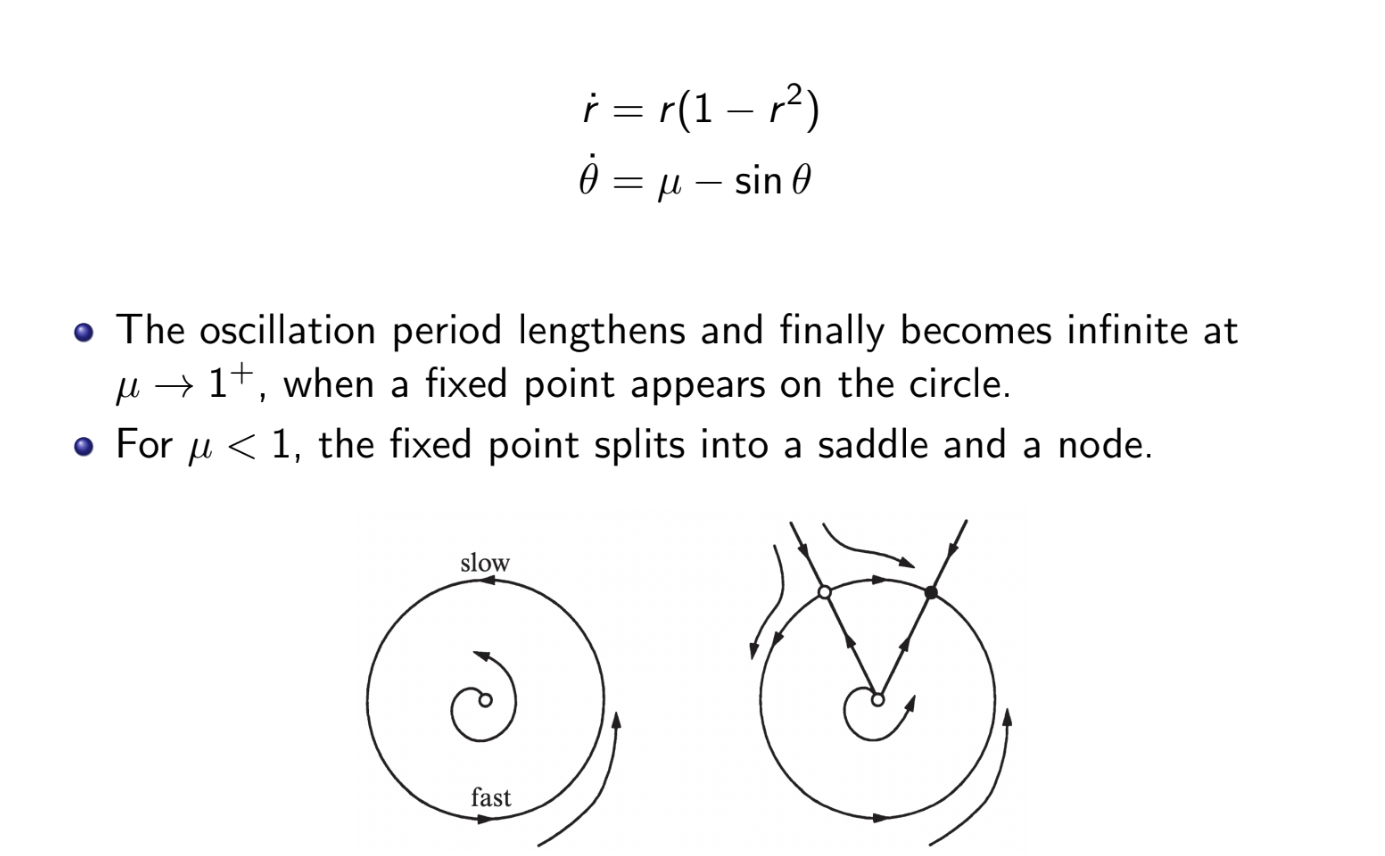

## code

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from ipywidgets import interact, FloatSlider

# infinite period bifurcation (SNIC)
# -------------------
# System definition
# -------------------
def system(t, z, mu):
    r, theta = z
    dr = r * (1 - r**2)
    dtheta = mu - np.sin(theta)
    return [dr, dtheta]

# -------------------
# Simulation
# -------------------
def simulate(mu, r0=0.5, theta0=0.0, t_end=50, npoints=1000):
    t_eval = np.linspace(0, t_end, npoints)
    sol = solve_ivp(system, [0, t_end], [r0, theta0], args=(mu,),
                    t_eval=t_eval, rtol=1e-6, atol=1e-9)
    return t_eval, sol.y[0], sol.y[1]

# -------------------
# Analytical period
# -------------------
def theta_period(mu):
    if abs(mu) <= 1.0:
        return np.inf  # infinite period at SNIC
    return 2 * np.pi / np.sqrt(mu**2 - 1)

def compute_period_curve(mu_min=-3.0, mu_max=-1.01, mu_min2=1.01, mu_max2=3.0, num_points=100):
    mu_values_neg = np.linspace(mu_min, mu_max, num_points)
    mu_values_pos = np.linspace(mu_min2, mu_max2, num_points)
    periods_neg = np.array([theta_period(mu) for mu in mu_values_neg])
    periods_pos = np.array([theta_period(mu) for mu in mu_values_pos])
    mu_values = np.concatenate([mu_values_neg, mu_values_pos])
    periods = np.concatenate([periods_neg, periods_pos])
    return mu_values, periods

# -------------------
# Interactive time series + period plot
# -------------------
def interactive_time_and_period(mu=1.5, r0=0.5, theta0=0.0):
    # --- simulate time series ---
    t, r, theta = simulate(mu, r0, theta0)
    x = r * np.cos(theta)
    y = r * np.sin(theta)

    # Compute angular velocity dθ/dt
    dtheta_dt = mu - np.sin(theta)
    # Normalize for colormap (slower velocity = darker color)
    norm = (dtheta_dt - np.min(dtheta_dt)) / (np.max(dtheta_dt) - np.min(dtheta_dt) + 1e-9)
    colors = plt.cm.Reds(1 - norm)  # slower = darker red

    fig = plt.figure(figsize=(16,8))

    # --- x(t) ---
    ax1 = plt.subplot2grid((2,3), (0,0))
    ax1.plot(t, x, lw=2, color='b')
    ax1.set_xlabel("Time t")
    ax1.set_ylabel("x(t)")
    ax1.set_title("x(t) = r cosθ")
    ax1.grid(True)

    # --- y(t) ---
    ax2 = plt.subplot2grid((2,3), (0,1))
    ax2.plot(t, y, lw=2, color='g')
    ax2.set_xlabel("Time t")
    ax2.set_ylabel("y(t)")
    ax2.set_title("y(t) = r sinθ")
    ax2.grid(True)

    # --- θ(t) with color highlighting slowing down ---
    ax3 = plt.subplot2grid((2,3), (0,2))
    for i in range(len(t)-1):
        ax3.plot(t[i:i+2], theta[i:i+2], color=colors[i], lw=2)
    ax3.set_xlabel("Time t")
    ax3.set_ylabel("θ(t)")
    ax3.set_title("Angular dynamics θ(t) (slowing highlighted)")
    ax3.grid(True)

    # --- Analytical period plot ---
    ax4 = plt.subplot2grid((2,1), (1,0), colspan=3)
    mu_vals, periods = compute_period_curve()
    ax4.plot(mu_vals, periods, lw=2)
    ax4.axvline(mu, color='r', ls='--', label=f"current μ={mu:.3f}")
    ax4.set_ylim(0, np.percentile(periods[np.isfinite(periods)], 95))
    ax4.set_xlabel("μ")
    ax4.set_ylabel("Period of θ(t)")
    ax4.set_title("Analytical Period vs μ")
    ax4.grid(True)
    ax4.legend()

    plt.tight_layout()
    plt.show()



In [ ]:
# -------------------
# Interactive widget
# -------------------
interact(
    interactive_time_and_period,
    mu=FloatSlider(value=1.5, min=-3.0, max=3.0, step=0.01, description="μ"),
    r0=FloatSlider(value=0.5, min=0.0, max=2.0, step=0.05, description="r0"),
    theta0=FloatSlider(value=0.0, min=-np.pi, max=np.pi, step=0.05, description="θ0")
)


interactive(children=(FloatSlider(value=1.5, description='μ', max=3.0, min=-3.0, step=0.01), FloatSlider(value…

<function __main__.interactive_time_and_period(mu=1.5, r0=0.5, theta0=0.0)>